# Проект Маркетинг

Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов требуется выделить пользователей,
которые готовы совершить покупку в ближайшее время.

**Цель проекта - Предсказать вероятность покупки в течение 90 дней.**

**Задачи:** изучить данные, разработать полезные признаки, создать модель для классификации пользователей, улучшить модель и максимизировать метрику roc_auc, выполнить тестирование.

**Данные:**

**apparel-purchases** - история покупок:

● client_id идентификатор пользователя

● quantity количество товаров в заказе

● price цена товара

● category_ids вложенные категории, к которым отнсится товар

● date дата покупки

● message_id идентификатор сообщения из рассылки

**apparel-messages** - история рекламных рассылок

● bulk_campaign_id идентификатор рекламной кампании

● client_id идентификатор пользователя

● message_id идентификатор сообщений

● event тип действия

● channel канал рассылки

● date дата рассылки

● created_at точное время создания сообщения

**apparel-target_binary** - совершит ли клиент покупку в течение следующих 90 дней

● client_id идентификатор пользователя

● target целевой признак


## Импорты

In [1]:
!pip install phik -q

!pip install scikit-learn -q

!pip install catboost -q

In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import shap

import ast

import warnings

RANDOM_STATE = 38

## Подготовка и анализ данных

Загрузим и проанализируем предложенные данные.

### apparel-target_binary

In [3]:
target_data = pd.read_csv('apparel-target_binary.csv')
target_data.head(3)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0


In [4]:
target_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [5]:
target_data.duplicated().sum()

0

Пропусков и полных дубликатов в датафреме нет, типы данных корректные.

#### client_id

In [6]:
target_data['client_id'].duplicated().sum()

0

In [7]:
target_data['client_id'].nunique()

49849

Целевой признак рассчитан для 49849 разных client_id.

#### target

In [8]:
target_data['target'].unique()

array([0, 1], dtype=int64)

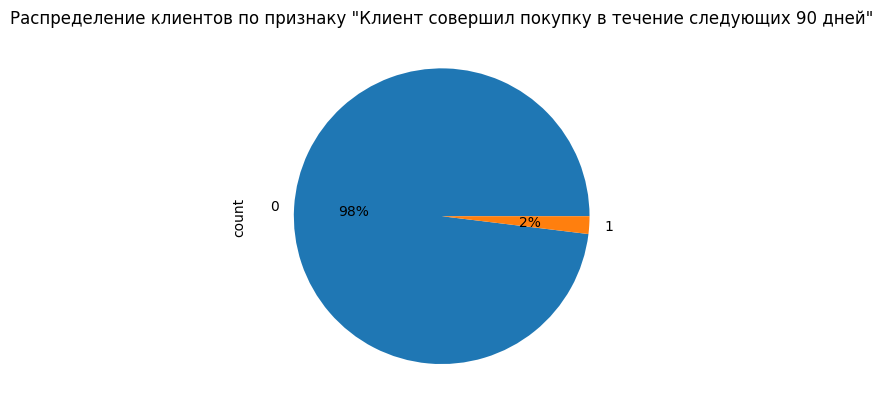

In [9]:
target_data['target'].value_counts().plot(kind='pie', grid=True, autopct='%1.0f%%')
plt.title('Распределение клиентов по признаку "Клиент совершил покупку в течение следующих 90 дней"')
plt.show()

Наблюдается дисбаланс между распределением классов - доля одного класса значительно превышает долю другого.
Клиентов, которые совершат покупку в течение следующих 90 дней, лишь 2%.

### apparel-purchases

In [10]:
purchases_data = pd.read_csv('apparel-purchases.csv')
purchases_data.head(3)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843


In [11]:
purchases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


In [12]:
purchases_data.duplicated().sum()

73020

Пропусков нет, типы данных корректные кроме столбца date.

Есть 73020 повторяющихся строк. Основания утверждать, что это дубликаты, у нас нет. Клиент мог в течение одного дня при получении одного сообщения купить несколько товаров из одной категории по одной цене. Даже если товар один и тот же, он может быть, например, разного цвета. В нашем случае мы не знаем даже один и тот же товар или нет, так как в данных нет id конкретного товара. 

Дублирующиеся строки сохраняем.

#### client_id

In [13]:
purchases_data['client_id'].nunique()

49849

Данные о покупках представлены, как и целевой признак, для 49849 разных client_id.

#### quantity

In [14]:
purchases_data['quantity'].nunique()

16

In [15]:
purchases_data['quantity'].describe()

count    202208.000000
mean          1.006483
std           0.184384
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          30.000000
Name: quantity, dtype: float64

In [16]:
purchases_data[purchases_data['quantity'] > 1]['quantity'].count()

885

In [17]:
purchases_data[purchases_data['quantity'] > 1]['quantity'].count()/purchases_data['quantity'].count()

0.0043766814369362245

In [18]:
purchases_data[purchases_data['quantity'] > 1]['quantity'].value_counts()

quantity
2     751
3      94
4      12
6       5
10      4
20      3
15      3
5       3
25      2
30      2
9       2
13      1
18      1
8       1
7       1
Name: count, dtype: int64

В 99,6% строк количество товара указано как 1. Что укрепляет наше предположение о том, что при покупке клиентом нескольких единиц товара одной категории, они попадают в разные строки датафрейма.

Проверим, не являются ли строки с количеством товара более 1 строками, суммирующими другие строки.

In [19]:
purchases_data[purchases_data['quantity'] == 4].head(3)

,client_id,quantity,price,category_ids,date,message_id
21426,1515915625559762595,4,15.0,"['5562', '5597', '5691', '889']",2022-07-08,1515915625471544776-5335-62c7d2c4cc9fd
33609,1515915625468078786,4,39.0,"['4', '1822', '5985', '476']",2022-08-26,1515915625468078786-5970-63085e0868424
68030,1515915625897931515,4,79.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781


In [20]:
purchases_data[purchases_data['client_id'] == 1515915625897931515	]

,client_id,quantity,price,category_ids,date,message_id
68029,1515915625897931515,6,149.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
68030,1515915625897931515,4,79.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
68031,1515915625897931515,1,199.0,"['6060', '6058', '6066', '5500']",2022-12-16,1515915625490318542-8722-639c17b49f781
68032,1515915625897931515,1,129.0,"['6060', '6058', '6061', '5504']",2022-12-16,1515915625490318542-8722-639c17b49f781


In [21]:
purchases_data[purchases_data['message_id'] == '1515915625490318542-8722-639c17b49f781']

,client_id,quantity,price,category_ids,date,message_id
66298,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66299,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66300,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66301,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66302,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66303,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66304,1515915625490318542,1,104.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66305,1515915625490318542,1,56.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66306,1515915625490318542,1,56.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781
66307,1515915625490318542,1,56.0,"['6060', '6058', '6067', '5498']",2022-12-16,1515915625490318542-8722-639c17b49f781


Строки  с количеством товара более 1 не являются строками, суммирующими другие строки. Видимо, это покупки абсолютно одного и того же товара в нескольких экземплярах. Или по этой части данных другой формат выгрузки (с объедиением нескольких товаров одной категории в одну строку). 

#### price

In [22]:
purchases_data['price'].describe()

count    202208.000000
mean       1193.301516
std        1342.252664
min           1.000000
25%         352.000000
50%         987.000000
75%        1699.000000
max       85499.000000
Name: price, dtype: float64

<AxesSubplot:>

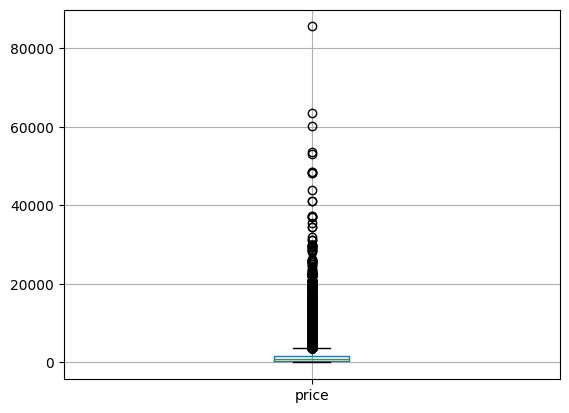

In [23]:
purchases_data.boxplot('price')

In [24]:
purchases_data[purchases_data['price'] < 10]['client_id'].count()/202208

0.039187371419528404

Распределение данных о цене товаров сильно смещено влево. 4% строк содержат данные о ценах менее 10 рублей.

Посмотрим на категории, в которых цена товара указана как 1 рубль.

In [25]:
purchases_data[purchases_data['price'] == 1]['category_ids'].sort_values().unique()

array(["['2', '17', '137', '469']", "['2', '17', '171', '475']",
       "['2', '17', '173', '459']", "['2', '17', '180', '465']",
       "['2', '17', '232', '463']", "['2', '17', '330', '387', '467']",
       "['2', '18', '123', '451']", "['2', '18', '212', '659']",
       "['2', '18', '212', '726']", "['2', '18', '258', '441']",
       "['2', '18', '267', '442']", "['2', '18', '344', '445']",
       "['2', '18', '61', '660']", "['4', '1822', '1821', '1613']",
       "['4', '1822', '1821', '1815']", "['4', '1822', '1821', '1816']",
       "['4', '1822', '1823', '1820']", "['4', '1822', '1824', '1623']",
       "['4', '1822', '1824', '1625']", "['4', '1822', '38', '478']",
       "['4', '1822', '38', '479']", "['4', '1822', '38', '480']",
       "['4', '1822', '38', '481']", "['4', '1822', '38', '482']",
       "['4', '1822', '5984', '5532']", "['4', '1822', '5984', '6019']",
       "['4', '1822', '5985', '1847']", "['4', '1822', '5985', '476']",
       "['4', '27', '138', '468']", "['4

In [26]:
purchases_data[purchases_data['price'] == 1]['client_id'].nunique()

378

Категории различны, клиенты, делавшие покупки за 1 рубль, не единичны.

In [27]:
purchases_data[purchases_data['price'] == 1].head()

,client_id,quantity,price,category_ids,date,message_id
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22154,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
32063,1515915625490679651,1,1.0,"['4', '28', '44', '1594']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32064,1515915625490679651,1,1.0,"['4', '28', '44', '1594']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32283,1515915625578652401,1,1.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f


In [28]:
purchases_data[purchases_data['client_id'] == 1515915625558323436]

,client_id,quantity,price,category_ids,date,message_id
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22154,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22155,1515915625558323436,1,2100.0,"['4', '28', '57', '431']",2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22156,1515915625558323436,1,2100.0,"['4', '28', '57', '431']",2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22157,1515915625558323436,1,1539.0,"['4', '28', '57', '431']",2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22158,1515915625558323436,1,1539.0,"['4', '28', '57', '431']",2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22159,1515915625558323436,1,2199.0,"['4', '28', '275', '673']",2022-07-09,1515915625487742246-5335-62c7d2d1281c7


In [29]:
purchases_data[purchases_data['client_id'] == 1515915625490679651]

,client_id,quantity,price,category_ids,date,message_id
32062,1515915625490679651,1,999.0,"['4', '28', '124', '415']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32063,1515915625490679651,1,1.0,"['4', '28', '44', '1594']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32064,1515915625490679651,1,1.0,"['4', '28', '44', '1594']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32065,1515915625490679651,1,10.0,"['4', '28', '124', '415']",2022-08-19,1515915625490679651-5922-62ff354e68cd3
32066,1515915625490679651,1,10.0,"['4', '28', '124', '415']",2022-08-19,1515915625490679651-5922-62ff354e68cd3


In [30]:
purchases_data[purchases_data['price'] == 2].head()

,client_id,quantity,price,category_ids,date,message_id
20226,1515915625558928490,1,2.0,"['5562', '5597', '5691', '889']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
21424,1515915625559762595,10,2.0,"['5562', '5597', '5691', '889']",2022-07-08,1515915625471544776-5335-62c7d2c4cc9fd
21425,1515915625559762595,10,2.0,"['5562', '5597', '5691', '889']",2022-07-08,1515915625471544776-5335-62c7d2c4cc9fd
23702,1515915625540239255,25,2.0,"['5562', '5597', '5691', '889']",2022-07-14,1515915625540239255-5403-62ce6dd7d68a1
23865,1515915625740853027,1,2.0,"['5562', '5597', '5691', '889']",2022-07-14,1515915625491240655-5403-62ce6db70596e


In [31]:
purchases_data[purchases_data['client_id'] == 1515915625558928490]

,client_id,quantity,price,category_ids,date,message_id
20223,1515915625558928490,1,399.0,"['4', '28', '239', '418']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20224,1515915625558928490,1,999.0,"['4', '28', '239', '418']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20225,1515915625558928490,1,499.0,"['4', '28', '239', '418']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20226,1515915625558928490,1,2.0,"['5562', '5597', '5691', '889']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20227,1515915625558928490,1,699.0,"['4', '28', '239', '418']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20228,1515915625558928490,1,499.0,"['4', '28', '239', '418']",2022-07-06,1515915625558928490-5286-62c52c06da8ee
20229,1515915625558928490,1,599.0,"['4', '28', '244', '432']",2022-07-06,1515915625558928490-5286-62c52c06da8ee


Среди покупок клиентов, делавших покупки за 1 или 2 рубля, есть и покупки за другие (большие) цены.

Вероятно, низкие цены в данных могут отражаться в учете в связи с какими-либо акциями (например, "3 платья по цене 2" - тогда 3-е будет отражено за 1 рубль) или скидками.

Выскокие цены покупок 85499 или около 60000 выглядят реалистичными, сохраним и их.

Для отображения распределения данных построим несколько гистограмм на разных интервалах.

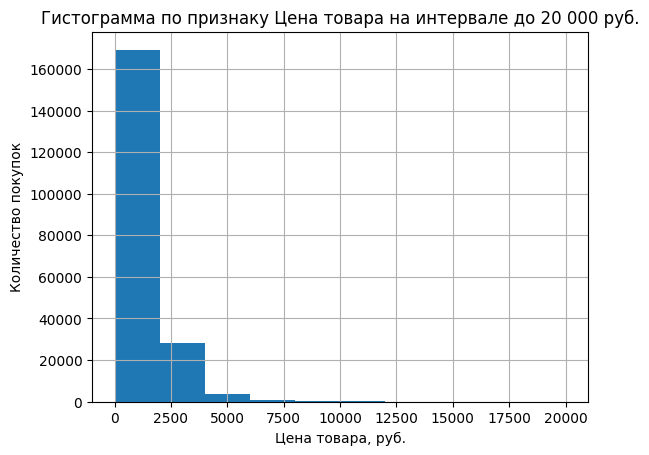

In [32]:
purchases_data[purchases_data['price'] <= 20000]['price'].hist()
plt.title('Гистограмма по признаку Цена товара на интервале до 20 000 руб.')
plt.xlabel('Цена товара, руб.')
plt.ylabel('Количество покупок')
plt.show()

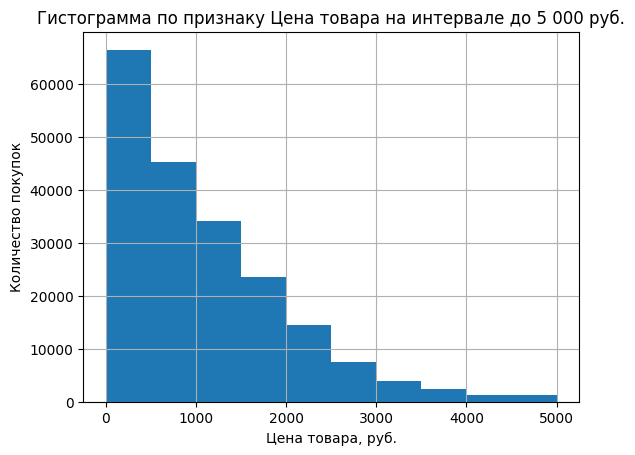

In [33]:
purchases_data[purchases_data['price'] <= 5000]['price'].hist()
plt.title('Гистограмма по признаку Цена товара на интервале до 5 000 руб.')
plt.xlabel('Цена товара, руб.')
plt.ylabel('Количество покупок')
plt.show()

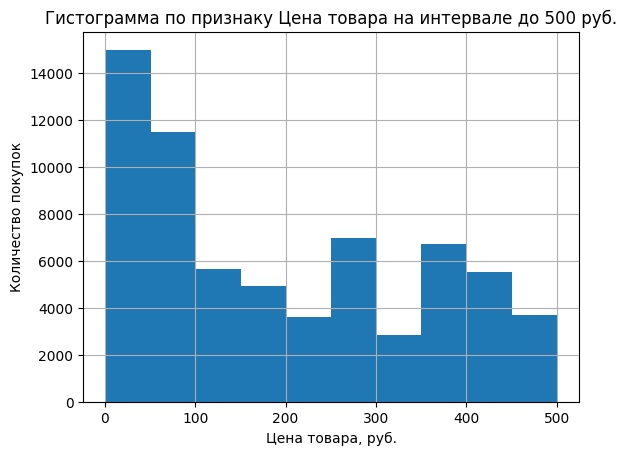

In [34]:
purchases_data[purchases_data['price'] <= 500]['price'].hist()
plt.title('Гистограмма по признаку Цена товара на интервале до 500 руб.')
plt.xlabel('Цена товара, руб.')
plt.ylabel('Количество покупок')
plt.show()

#### category_ids

In [35]:
purchases_data['category_ids'].nunique()

933

In [36]:
purchases_data['category_ids'].sort_values().unique()

array(["['1', '22', '50', '685']", "['1', '8', '280', '710']",
       "['2', '17', '107', '453']", "['2', '17', '137', '469']",
       "['2', '17', '171', '475']", "['2', '17', '173', '1598']",
       "['2', '17', '173', '1845']", "['2', '17', '173', '459']",
       "['2', '17', '180', '465']", "['2', '17', '1826', '1818']",
       "['2', '17', '188', '525']", "['2', '17', '198', '497']",
       "['2', '17', '232', '463']", "['2', '17', '279', '5807']",
       "['2', '17', '286', '455']", "['2', '17', '293', '5819']",
       "['2', '17', '330', '387', '467']", "['2', '17', '83', '519']",
       "['2', '17', '83', '5810']", "['2', '18', '123', '451']",
       "['2', '18', '155', '1325']", "['2', '18', '155', '439']",
       "['2', '18', '212', '658']", "['2', '18', '212', '659']",
       "['2', '18', '212', '726']", "['2', '18', '217', '662']",
       "['2', '18', '217', '663']", "['2', '18', '243', '440']",
       "['2', '18', '248', '449']", "['2', '18', '248', '677']",
       "['2', 

Категории товаров являются вложенными. Наблюдаем частое повторение категорий 1 и 2 уровня.

Есть покупки, по которым категория не указана. Посмотрим на них.

In [37]:
purchases_data['category_ids'] = purchases_data['category_ids'].replace('[None]', '[]')

In [38]:
purchases_data[purchases_data['category_ids'] == '[]']['category_ids'].count()

6843

In [39]:
purchases_data[purchases_data['category_ids'] == '[]'].head()

,client_id,quantity,price,category_ids,date,message_id
14848,1515915625649908756,1,2499.0,[],2022-06-17,1515915625649908756-4981-62ac2dbf52fad
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
22154,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7
32281,1515915625578652401,1,8.0,[],2022-08-19,1515915625815834300-5922-62ff35494e05f
32282,1515915625578652401,1,8.0,[],2022-08-19,1515915625815834300-5922-62ff35494e05f


Возможно, есть товары, не внесенные в базу категорий. По другим признакам строки с пустыми категориями заполнены. Сохраним данные.

Выделим отдельными стробцами категории 1 и 2 уровня.

In [40]:
purchases_data['category_ids_list'] = purchases_data['category_ids'].apply(ast.literal_eval)

In [41]:
purchases_data['category_first'] = purchases_data['category_ids_list'].apply(
    lambda x: int(x[0]) if len(x) >= 1 else None
)

In [42]:
purchases_data['category_second'] = purchases_data['category_ids_list'].apply(
    lambda x: int(x[1]) if len(x) >= 2 else None
)

In [43]:
purchases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   client_id          202208 non-null  int64  
 1   quantity           202208 non-null  int64  
 2   price              202208 non-null  float64
 3   category_ids       202208 non-null  object 
 4   date               202208 non-null  object 
 5   message_id         202208 non-null  object 
 6   category_ids_list  202208 non-null  object 
 7   category_first     195365 non-null  float64
 8   category_second    195365 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 13.9+ MB


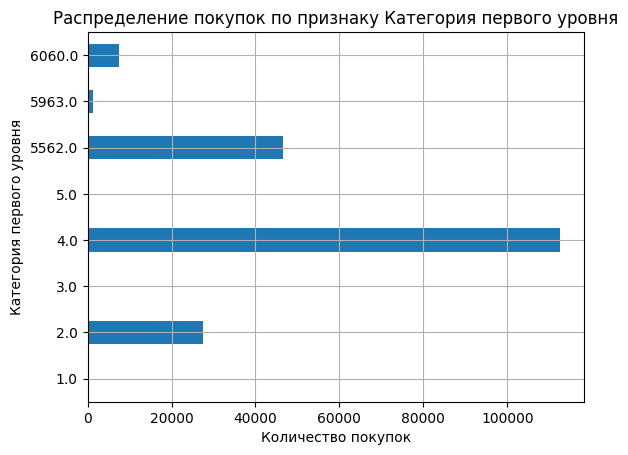

In [44]:
purchases_data.groupby('category_first')['category_first'].count().plot(kind='barh', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение покупок по признаку Категория первого уровня')
plt.xlabel('Количество покупок')
plt.ylabel('Категория первого уровня')
plt.show()

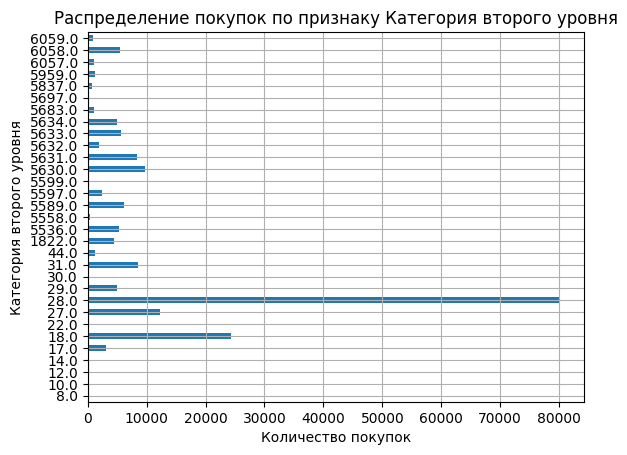

In [45]:
purchases_data.groupby('category_second')['category_second'].count().plot(kind='barh', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение покупок по признаку Категория второго уровня')
plt.xlabel('Количество покупок')
plt.ylabel('Категория второго уровня')
plt.show()

Покупки распределены по категориям неравномерно, что нормально для одежды.

Для признаков модели возьмем столбец category_first. Категорий 2 уровня всё же довольно много.

Строки, где категории не указаны, на данном этапе не будем обрабатывать. Данные ещё будут агрегироваться по id клиентов. Посмотрим, будут ли пропуски в сводной таблице.

#### date

In [46]:
purchases_data['date'].nunique()

642

In [47]:
purchases_data['date'] = pd.to_datetime(purchases_data['date'])
purchases_data['year'] = purchases_data['date'].dt.year
purchases_data['month'] = purchases_data['date'].dt.month

purchases_data['year'].value_counts()

year
2023    109680
2022     81621
2024     10907
Name: count, dtype: int64

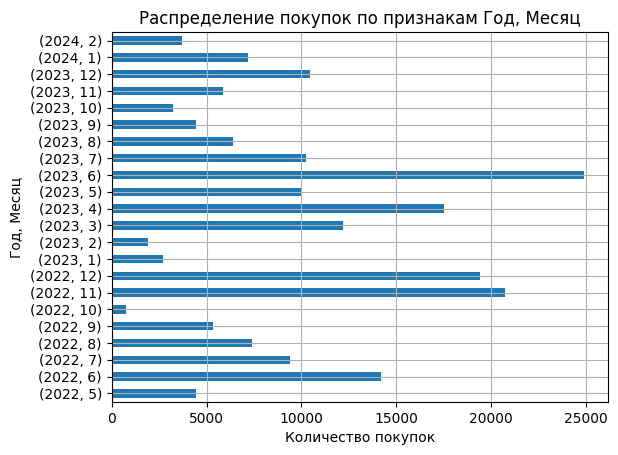

In [48]:
purchases_data.groupby(['year', 'month'])['date'].count().plot(kind='barh', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение покупок по признакам Год, Месяц')
plt.xlabel('Количество покупок')
plt.ylabel('Год, Месяц')
plt.show()

Представлены данные о покупках с мая 2022 года по февраль 2024 гг.

Обратим внимание, люди покупают большее количество предметов одежды в начале лета и перед Новым годом / в начале зимы.

#### message_id

In [49]:
purchases_data['message_id'].nunique()

50204

In [50]:
purchases_data['message_id'].sort_values().unique()

array(['1515915625468060902-4617-6290657dac196',
       '1515915625468061003-9148-63b54b04855a4',
       '1515915625468061099-4439-62834141aa538', ...,
       '1515915626010152263-14649-65cca1b63edf7',
       '1515915626010221592-14664-65cf1622434a9',
       '1515915626010261344-14648-65cdb6d56c4c8'], dtype=object)

In [51]:
purchases_data.groupby('message_id')['message_id'].count().sort_values().unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  66,
        67,  69,  70,  72,  75,  86,  87,  89,  91,  96, 103, 108, 111,
       143, 148, 160, 218, 365], dtype=int64)

На каждое message_id приходилось от 1 до 365 покупок.

In [52]:
purchases_data.groupby('message_id')['client_id'].nunique().value_counts()

client_id
1     42211
2      7951
3        35
5         3
4         3
87        1
Name: count, dtype: int64

По сообщению с одним message_id могли совершить покупки от 1 до 87 клиентов.

In [53]:
purchases_data.groupby('client_id')['message_id'].nunique().value_counts()

message_id
1     43845
2      4538
3       922
4       326
5       118
6        46
7        21
8        14
9         7
10        5
11        4
15        1
27        1
17        1
Name: count, dtype: int64

Один и тот же клиент мог купить что-либо, воспользовавшись от 1 до 27 сообщениями.

### apparel-messages

In [54]:
messages_data = pd.read_csv('apparel-messages.csv')
messages_data.head(3)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49


In [55]:
messages_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [56]:
messages_data.duplicated().sum()

48610

Иипы данных корректные кроме столбцов с датами.

Есть 48610 повторяющихся строк. Вероятнее всего, это дуликаты, так как в столбце created_at указано время с точностью до секунд. Проверим предположение при анализе дат.

#### bulk_campaign_id

In [57]:
messages_data['bulk_campaign_id'].nunique()

2709

In [58]:
messages_data['bulk_campaign_id'].sort_values().unique()

array([  548,   563,   585, ..., 14655, 14656, 14657], dtype=int64)

Пропусков в стобце с id рекламной компании нет.

#### client_id

In [59]:
messages_data['client_id'].nunique()

53329

In [60]:
messages_data['client_id'].sort_values().unique()

array([1515915625468060902, 1515915625468061003, 1515915625468061099, ...,
       1515915626010234726, 1515915626010261344, 1515915626010288690],
      dtype=int64)

Пропусков в стобце с id клиентов также нет.

Уникальных id больше, чем в датафреймах с покуками и таргетом. Клиентов, которым отправлялись сообщения больше, чем клиентов, делавших покупки.

#### message_id

In [61]:
messages_data['message_id'].nunique()

9061667

In [62]:
messages_data['message_id'].sort_values().unique()

array(['1515915625468060902-10022-63e5ededd911f',
       '1515915625468060902-10218-63ef56ed94656',
       '1515915625468060902-10289-63f35a8a9ff35', ...,
       '1515915626010234726-14656-65cdd2f839b78',
       '1515915626010261344-14648-65cdb6d56c4c8',
       '1515915626010288690-14648-65cdb6d29b698'], dtype=object)

Пропусков в стобце с id сообщений нет.

#### date

In [63]:
messages_data['date'].nunique()

638

In [64]:
messages_data['date'] = pd.to_datetime(messages_data['date'])
messages_data['date'].dt.year.value_counts()

date
2023    7665613
2022    3456161
2024    1618024
Name: count, dtype: int64

In [65]:
messages_data['date'].isna().sum()

0

Годы отправки сообщений те же, что годы в данных о покупках. Пропусков нет.

#### created_at

In [66]:
messages_data['created_at'].nunique()

4103539

In [67]:
messages_data['created_at'] = pd.to_datetime(messages_data['created_at'])
messages_data['created_at'].dt.year.value_counts()

created_at
2023    7665613
2022    3456161
2024    1618024
Name: count, dtype: int64

In [68]:
messages_data['created_at'].isna().sum()

0

Пропусков нет.

In [69]:
messages_data['date'].dt.date.eq(messages_data['created_at'].dt.date).sum()

12739798

По всех строках даты в столбце date и столбце created_at совпадают. Значит, date - это тоже дата создания сообщения без указания времени. 

In [70]:
messages_data.groupby('created_at')['message_id'].nunique().value_counts()

message_id
1      1867715
2       815399
3       458111
4       278583
5       180325
        ...   
271          1
412          1
229          1
368          1
304          1
Name: count, Length: 268, dtype: int64

В одну секунду могло быть создано несколько сообщений с одним id.

In [71]:
messages_data.groupby('message_id')['created_at'].nunique().value_counts()

created_at
1      6051097
2      2695627
3       202551
4        62471
5        24543
        ...   
92           1
147          1
103          1
102          1
44           1
Name: count, Length: 73, dtype: int64

In [72]:
messages_data.groupby(['client_id', 'message_id'])['created_at'].nunique().value_counts()

created_at
1      6051097
2      2695627
3       202551
4        62471
5        24543
        ...   
92           1
147          1
103          1
102          1
44           1
Name: count, Length: 73, dtype: int64

Для одного клиента одно сообщение могло создаваться несколько раз.

Удалим из датафрейма полные дубликаты (одинаковые сообщения, созданные в одну секунду).

In [73]:
messages_data = messages_data.drop_duplicates()

In [74]:
messages_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12691188 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  int64         
 1   client_id         int64         
 2   message_id        object        
 3   event             object        
 4   channel           object        
 5   date              datetime64[ns]
 6   created_at        datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 774.6+ MB


In [75]:
messages_data['year'] = messages_data['date'].dt.year
messages_data['month'] = messages_data['date'].dt.month

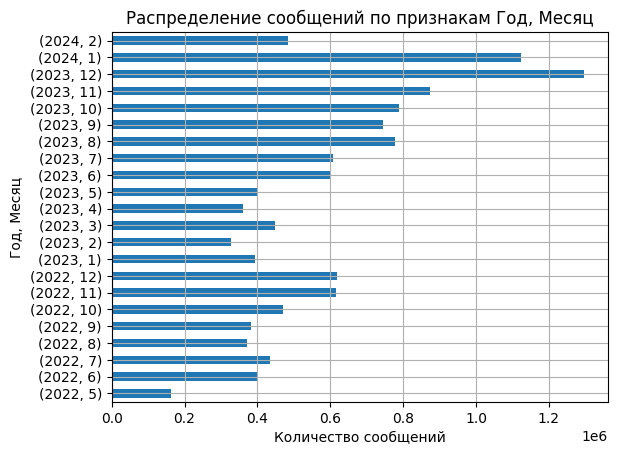

In [76]:
messages_data.groupby(['year', 'month'])['date'].count().plot(kind='barh', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение сообщений по признакам Год, Месяц')
plt.xlabel('Количество сообщений')
plt.ylabel('Год, Месяц')
plt.show()

Активность компании по рассылке сообщений увеличивалась на анализируемом периоде.

#### event	

In [77]:
messages_data['event'].unique()

array(['open', 'click', 'purchase', 'send', 'unsubscribe', 'hbq_spam',
       'hard_bounce', 'subscribe', 'soft_bounce', 'complain', 'close'],
      dtype=object)

В переводе на русский: "открыто", "нажато", "покупка", "отправлено", "отказ от подписки", "hbq_spam", "жесткий отказ", "подписка", "мягкий отказ", "жалоба", "закрыто"

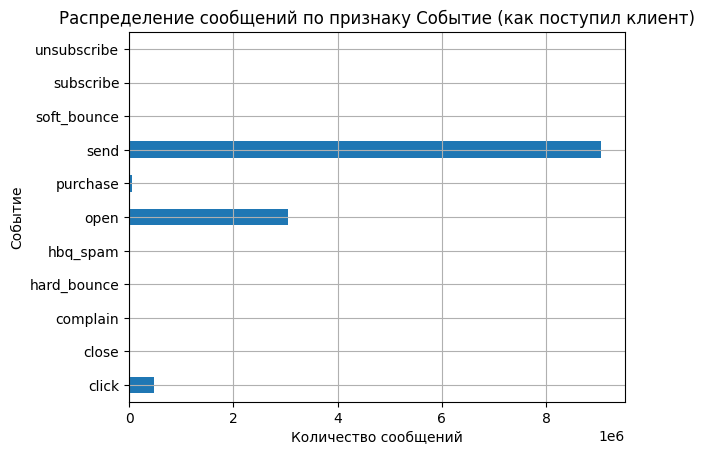

In [78]:
messages_data.groupby('event')['event'].count().plot(kind='barh', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение сообщений по признаку Событие (как поступил клиент)')
plt.xlabel('Количество сообщений')
plt.ylabel('Событие')
plt.show()

In [79]:
messages_data[messages_data['event'] == 'purchase']['event'].count()

62593

In [80]:
messages_data[messages_data['event'] == 'purchase']['message_id'].nunique()

49671

Уникальных message_id, по которым были сделаны покупки, в данном датафрейме меньше, чем в датафрейме с покупками. 

In [81]:
messages_data[messages_data['event'] == 'purchase']['client_id'].nunique()

42055

Уникальных клиентов, сделавших покупки, в данном датафрейме также меньше, чем в датафрейме с покупками. 

На данном этапе просто обратим внимание, так как объединять данные будем опираясь на перечень клиентов, для которых рассчитан  таргет.

#### channel

In [82]:
messages_data['channel'].unique()

array(['email', 'mobile_push'], dtype=object)

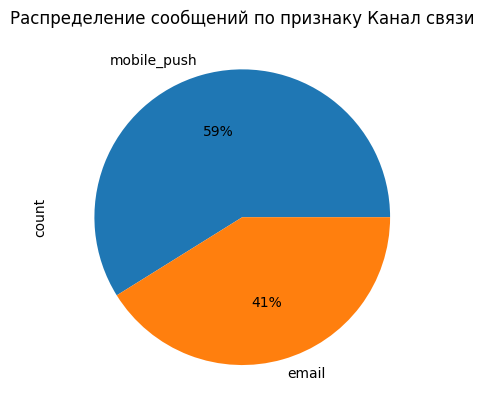

In [83]:
messages_data['channel'].value_counts().plot(kind='pie', grid=True, autopct='%1.0f%%')
plt.title('Распределение сообщений по признаку Канал связи')
plt.show()

In [84]:
messages_data.groupby('message_id')['channel'].nunique().value_counts()

channel
1    9061667
Name: count, dtype: int64

Более популярны пуш-уведомления. Каждому message_id соответствует только 1 канал.

## Объединние данных

### messages_data

Агрегируем по id клиентов датафрейм messages_data.

In [85]:
messages_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12691188 entries, 0 to 12739797
Data columns (total 9 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  int64         
 1   client_id         int64         
 2   message_id        object        
 3   event             object        
 4   channel           object        
 5   date              datetime64[ns]
 6   created_at        datetime64[ns]
 7   year              int32         
 8   month             int32         
dtypes: datetime64[ns](2), int32(2), int64(2), object(3)
memory usage: 871.4+ MB


In [86]:
messages_client_pivot = messages_data.groupby('client_id').agg(
    messages_count=('message_id', 'count'),
    event_mode=('event', lambda x: x.mode()[0] if not x.mode().empty else None),
    purchase_share=('event', lambda x: round(((x == 'purchase').mean()), 3))
).reset_index()

messages_client_pivot.head(3)

,client_id,messages_count,event_mode,purchase_share
0,1515915625468060902,177,send,0.028
1,1515915625468061003,165,send,0.006
2,1515915625468061099,276,send,0.000


In [87]:
messages_client_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53329 entries, 0 to 53328
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   client_id       53329 non-null  int64  
 1   messages_count  53329 non-null  int64  
 2   event_mode      53329 non-null  object 
 3   purchase_share  53329 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.6+ MB


### Канал получения сообщения

Создадим датафрейм, в котором для каждого message_id укажем канал отправки.

In [88]:
message_channel = messages_data[['message_id', 'channel']].groupby('message_id').first()

In [89]:
message_channel.head(3)

,channel
message_id,
1515915625468060902-10022-63e5ededd911f,email
1515915625468060902-10218-63ef56ed94656,email
1515915625468060902-10289-63f35a8a9ff35,email


In [90]:
message_channel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9061667 entries, 1515915625468060902-10022-63e5ededd911f to 1515915626010288690-14648-65cdb6d29b698
Data columns (total 1 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   channel  object
dtypes: object(1)
memory usage: 138.3+ MB


Добавим в датафрейм с покупками информацию о канале получения сообщения.

In [91]:
purchases_data = pd.merge(purchases_data, message_channel, on='message_id', how='left')

In [92]:
purchases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   client_id          202208 non-null  int64         
 1   quantity           202208 non-null  int64         
 2   price              202208 non-null  float64       
 3   category_ids       202208 non-null  object        
 4   date               202208 non-null  datetime64[ns]
 5   message_id         202208 non-null  object        
 6   category_ids_list  202208 non-null  object        
 7   category_first     195365 non-null  float64       
 8   category_second    195365 non-null  float64       
 9   year               202208 non-null  int32         
 10  month              202208 non-null  int32         
 11  channel            201352 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(2), int64(2), object(4)
memory usage: 17.0+ MB


### purchases_data

Агрегируем по id клиентов датафрейм purchases_data.

In [93]:
purchases_client_pivot = purchases_data.pivot_table(
    values=['quantity', 'price', 'category_first', 'year', 'message_id', 'channel'],
    index='client_id',
    aggfunc={
        'quantity': 'sum',
        'price':  lambda x: round(x.mean(), 2),
        'category_first': lambda x: x.mode()[0] if not x.mode().empty else None,
        'year': 'max',
        'channel': lambda x: x.mode()[0] if not x.mode().empty else None
    }
)

purchases_client_pivot.columns = ['category_first_mode', 'channel_mode', 'price_mean', 'quantity_sum', 'year_last_purchase']

purchases_client_pivot.head(3)

,category_first_mode,channel_mode,price_mean,quantity_sum,year_last_purchase
client_id,,,,,
1515915625468060902,4.0,email,999.00,7,2022
1515915625468061003,4.0,email,2319.29,7,2023
1515915625468061099,4.0,None,299.00,1,2022


In [94]:
purchases_client_pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49849 entries, 1515915625468060902 to 1515915626010443624
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category_first_mode  49848 non-null  float64
 1   channel_mode         49589 non-null  object 
 2   price_mean           49849 non-null  float64
 3   quantity_sum         49849 non-null  int64  
 4   year_last_purchase   49849 non-null  int32  
dtypes: float64(2), int32(1), int64(1), object(1)
memory usage: 2.1+ MB


### Объединение сводных таблиц

Для начала к данным с таргетом присоедним  purchases_client_pivot. В этих данных количество уникальных client_id одинаковое.

In [95]:
data = pd.merge(target_data, purchases_client_pivot, on='client_id', how='left')

In [96]:
data.head(3)

,client_id,target,category_first_mode,channel_mode,price_mean,quantity_sum,year_last_purchase
0,1515915625468060902,0,4.0,email,999.00,7,2022
1,1515915625468061003,1,4.0,email,2319.29,7,2023
2,1515915625468061099,0,4.0,None,299.00,1,2022


In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            49849 non-null  int64  
 1   target               49849 non-null  int64  
 2   category_first_mode  49848 non-null  float64
 3   channel_mode         49589 non-null  object 
 4   price_mean           49849 non-null  float64
 5   quantity_sum         49849 non-null  int64  
 6   year_last_purchase   49849 non-null  int32  
dtypes: float64(2), int32(1), int64(3), object(1)
memory usage: 2.5+ MB


Пропуски образовались только в столбце channel_mode. Эти данные были взяты их датафрейма сообщениями, где другое количество id клиентов с покупками и id сообщений. И, раз образовались пропуски, есть несоответствие списков id.

Добавим messages_client_pivotю

In [98]:
data = pd.merge(data, messages_client_pivot, on='client_id', how='left')

data.head(3)

,client_id,target,category_first_mode,channel_mode,price_mean,quantity_sum,year_last_purchase,messages_count,event_mode,purchase_share
0,1515915625468060902,0,4.0,email,999.00,7,2022,177.0,send,0.028
1,1515915625468061003,1,4.0,email,2319.29,7,2023,165.0,send,0.006
2,1515915625468061099,0,4.0,None,299.00,1,2022,276.0,send,0.000


In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            49849 non-null  int64  
 1   target               49849 non-null  int64  
 2   category_first_mode  49848 non-null  float64
 3   channel_mode         49589 non-null  object 
 4   price_mean           49849 non-null  float64
 5   quantity_sum         49849 non-null  int64  
 6   year_last_purchase   49849 non-null  int32  
 7   messages_count       41982 non-null  float64
 8   event_mode           41982 non-null  object 
 9   purchase_share       41982 non-null  float64
dtypes: float64(4), int32(1), int64(3), object(2)
memory usage: 3.6+ MB


**Получили датафрейм со следующими признаками для построения модели:**

- category_first_mode - категория первого уровня, в которой клиент сделал большее количество покупок

- channel_mode - канал получения сообщений, на основании которых клиент сделал большее количество покупок

- price_mean - средняя цена купенного товара

- quantity_sum количество купленных товаров

- year_last_purchase - год, в котором сделана последняя покупка (год выгрузки 2024, предыдущий 2023 или 2022)

- messages_count - количество отправленных клиенту сообщений

- event_mode - наиболее частое действие с сообщением у данного клиента

- purchase_share - доля сообщений, отправленных клиенту, которые привели к покупкам.

По причине несоответствия данных получили более 8 тыс. пропусков. Основания заполнить эти пропуски у нас нет. Признаки messages_count, event_mode, purchase_share видятся полезными. Удалим строки с пропусками. 

In [100]:
data_clean = data.dropna()

data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41744 entries, 0 to 49844
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            41744 non-null  int64  
 1   target               41744 non-null  int64  
 2   category_first_mode  41744 non-null  float64
 3   channel_mode         41744 non-null  object 
 4   price_mean           41744 non-null  float64
 5   quantity_sum         41744 non-null  int64  
 6   year_last_purchase   41744 non-null  int32  
 7   messages_count       41744 non-null  float64
 8   event_mode           41744 non-null  object 
 9   purchase_share       41744 non-null  float64
dtypes: float64(4), int32(1), int64(3), object(2)
memory usage: 3.3+ MB


## Корреляционный анализ

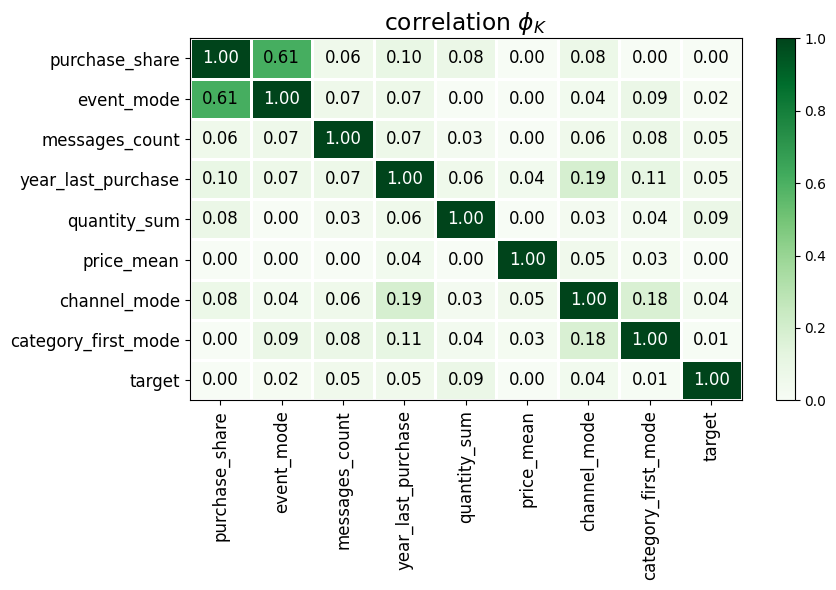

In [101]:
interval_cols = ['price_mean', 'quantity_sum', 'messages_count', 'purchase_share']

phik_overview = phik_matrix(data_clean.drop('client_id', axis=1), interval_cols=interval_cols) 

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.2,
    figsize=(9, 6)
) 

**К сожалению, в матрице корреляций видим низкую или нулевую связь целевого признака с признаками, созданными на основе данных.**

 При этом многие модели могут улавливать более слодные связи признаков. Также признаки могут влиять на таргет вместе существеннее, чем по отдельости. Попробуем обучить ряд моделей.

## Использование пайплайнов

### Подготовка выборок
Создадим датафреймы Х и y.

In [102]:
X = data_clean.drop(['client_id', 'target'], axis=1)
y = data_clean['target']

Разделим датафреймы на выборки.

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)

In [104]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size = 0.25, random_state = RANDOM_STATE, stratify = y_train)

In [105]:
display(X_train.shape)
display(X_valid.shape)
X_test.shape

(25046, 8)

(8349, 8)

(8349, 8)

### Пайплайн
Списки признаков для кодирования и масштабирования:

In [106]:
ohe_columns = ['category_first_mode', 'channel_mode', 'event_mode']
ord_columns = ['year_last_purchase']
num_columns = ['price_mean', 'quantity_sum', 'messages_count', 'purchase_share']

Кодирование:

In [107]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
) 

In [108]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    [2022, 2023, 2024]
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

Собираем пайплайн:

In [109]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False
) 

In [110]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

### Подбор модели и гиперпараметров

In [111]:
param_grid = [

    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 8),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [112]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

display('Лучшая модель:\n', grid_search.best_estimator_)
display('Пареметры лучшей модели:\n', grid_search.best_params_)
'ROC-AUC лучшей модели на тренировочной выборке:', grid_search.best_score_

'Лучшая модель:\n'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['category_first_mode',
                                                   'channel_mode',
                                                   'event_mode']),
                                                 ('ord',
                                                  Pipe...
                                                                   OrdinalEncoder(categories=[[2022,
                                                                                               2023,
                                                                                               2024]],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['year_last_purchase']),
                                                 ('num', StandardScaler(),
                                                  ['price_mean', 'quantity_sum',
                                                   'messages_count',
                                                   'purchase_share'])])),
                ('models',
                 LogisticRegression(C=1, penalty='l1', random_state=38,
                                    solver='liblinear'))])

'Пареметры лучшей модели:\n'

{'models': LogisticRegression(penalty='l1', random_state=38, solver='liblinear'),
 'models__C': 1,
 'preprocessor__num': StandardScaler()}

('ROC-AUC лучшей модели на тренировочной выборке:', 0.6963386933646201)

In [113]:
probabilities_valid = grid_search.predict_proba(X_valid)
f'ROC-AUC на валидационной выборке: {roc_auc_score(y_valid, probabilities_valid[:, 1])}'

'ROC-AUC на валидационной выборке: 0.7170887392972102'

Отобрана модель логистической регресии. 

Задача Заказчика - ROC-AUC не менее 0,7.

ROC-AUC на тренировочной выборке чуть меньше 0,696, на валидационной - 0,717.

In [114]:
pred_valid = grid_search.predict(X_valid)

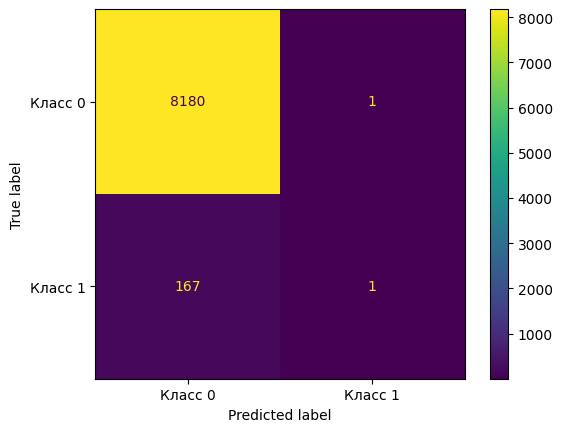

In [115]:
cm = confusion_matrix(y_valid, pred_valid)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1']).plot()
plt.show()

Несмотря на удовлетводительную ROC-AUC, модель на валидационной выборке не полезна. Она отнесла почти все объекты к преобладающему классу - 0. Recall этой модель близок к 0, мы не нашли объекты класса 1.

Можем попробовать:
- изменить состав признаков;
- обучить более сложную модель;
- настроить порог для получения более высокого recall.


### Анализ важности признаков

При объединении данных после присоединния признаков, полученных из messages_data, мы удалили более 8000 строк, так как в messages_data нет части клиентов. Возможно, стоит отказаться от данных признаков и вернуть удаленные строки. Оцениим важность признаков для лучшей модели с помощью метода SHAP.

Преобразуем X_test при помощи препроцессора лучшей модели:

In [116]:
X_valid_p = pd.DataFrame(grid_search.best_estimator_.named_steps['preprocessor'].transform(X_valid), \
                        columns=grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()) 

In [117]:
explainer = shap.LinearExplainer(grid_search.best_estimator_.named_steps['models'], X_valid_p)
shap_values = explainer(X_valid_p)

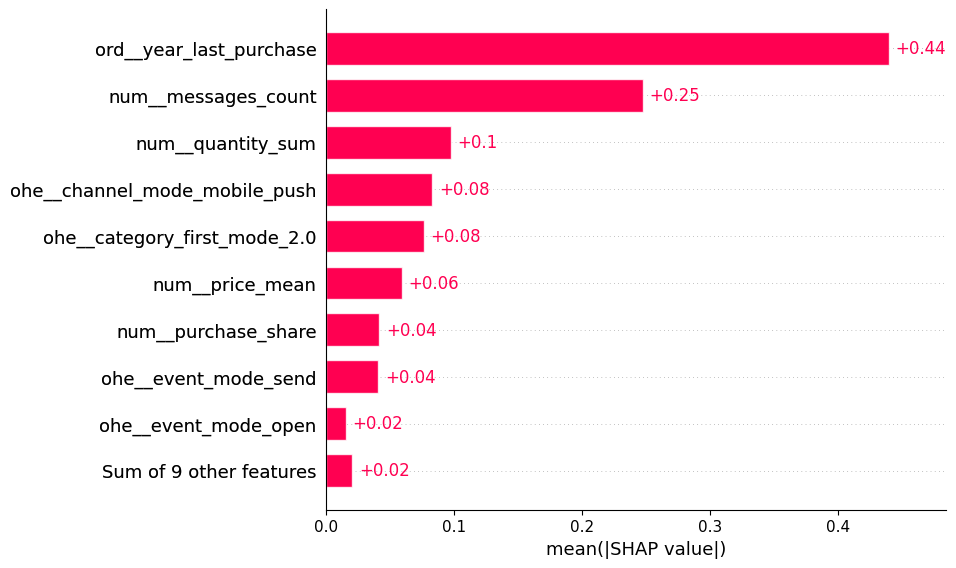

In [118]:
shap.plots.bar(shap_values, max_display=10)

Признаки, полученные из messages_data, находятся на высоких местах по важности - на 2, 4.

Сохраним признаки, откажемся от возврата строк.

**Протестируем модель логистической регрессии на тестовой выборке.**

In [119]:
probabilities_test = grid_search.predict_proba(X_test)
f'ROC-AUC на тестовой выборке: {roc_auc_score(y_test, probabilities_test[:, 1])}'

'ROC-AUC на тестовой выборке: 0.6990402413257198'

In [120]:
pred_test = grid_search.predict(X_test)

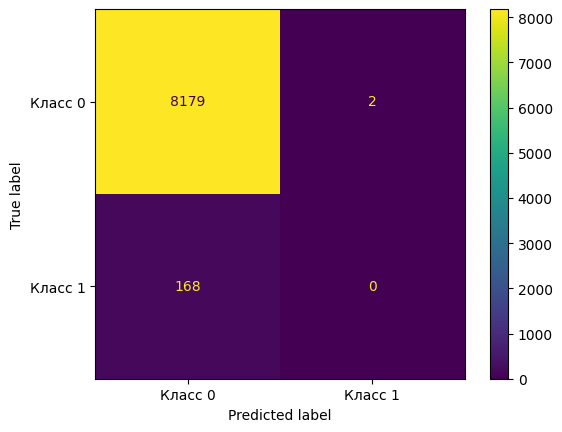

In [121]:
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1']).plot()
plt.show()

ROC-AUC модели логистической регрессии на тестовой выборке 0,699. Картина на confusion_matrix та же, что и для валидационной выборки.

Попробуем применить более сложную модель.

### CatBoostClassifier

Уберем из пайплайна модели, не отобранные на предущем шаге.

Добавим CatBoostClassifier и подберем для него гиперпараметры.

In [122]:
param_grid_2 = [

    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 2),
        'preprocessor__num': [StandardScaler(), 'passthrough']  
    },
    
    {
        'models': [CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=False,       
            thread_count=4,      
            allow_writing_files=False  
        )],
        'models__iterations': [80, 100],      
        'models__learning_rate': [0.1, 0.5],  
        'models__depth': [3, 8],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [123]:
grid_search_2 = GridSearchCV(
    pipe_final, 
    param_grid=param_grid_2, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_2.fit(X_train, y_train)

display('Лучшая модель:\n', grid_search_2.best_estimator_)
display('Пареметры лучшей модели:\n', grid_search_2.best_params_)
'ROC-AUC лучшей модели на тренировочной выборке:', grid_search_2.best_score_

'Лучшая модель:\n'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['category_first_mode',
                                                   'channel_mode',
                                                   'event_mode']),
                                                 ('ord',
                                                  Pipe...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['year_last_purchase']),
                                                 ('num', StandardScaler(),
                                                  ['price_mean', 'quantity_sum',
                                                   'messages_count',
                                                   'purchase_share'])])),
                ('models',
                 CatBoostClassifier(allow_writing_files=False, depth=3, iterations=100, learning_rate=0.1, random_state=38, thread_count=4, verbose=False))])

'Пареметры лучшей модели:\n'

{'models': CatBoostClassifier(allow_writing_files=False, random_state=38, thread_count=4, verbose=False),
 'models__depth': 3,
 'models__iterations': 100,
 'models__learning_rate': 0.1,
 'preprocessor__num': StandardScaler()}

('ROC-AUC лучшей модели на тренировочной выборке:', 0.7028485950163365)

In [124]:
probabilities_valid_2 = grid_search_2.predict_proba(X_valid)
f'ROC-AUC на валидационной выборке: {roc_auc_score(y_valid, probabilities_valid_2[:, 1])}'

'ROC-AUC на валидационной выборке: 0.7241481423274603'

Отобрана модель с ROC-AUC на тренировочной выборке чуть более 0,703.

На валидационной выборке метрика лучше - 0,724.

Построим confusion_matrix.

In [125]:
pred_valid_2 = grid_search_2.predict(X_valid)

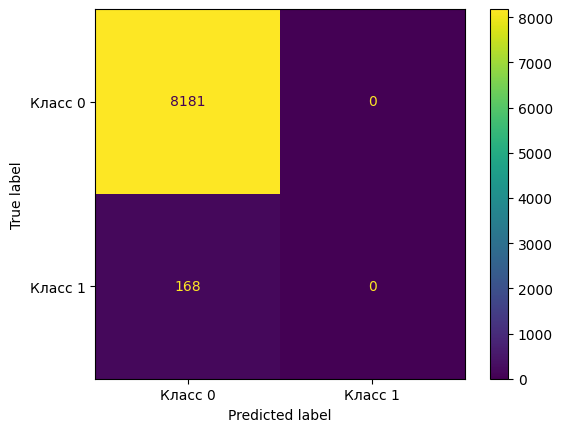

In [126]:
cm = confusion_matrix(y_valid, pred_valid_2)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1']).plot()
plt.show()

CatBoostClassifier, как и логистическая регрессия, не нашел объекты класса 1.

### Настройка порога значимости
Попробуем настроить попрог для модели CatBoostClassifier, так как она показала удовлетворительные, более высокие значения ROC_AUC.

In [127]:
preds_probas_2_valid = pd.DataFrame(zip(y_valid, pred_valid_2, probabilities_valid_2[:, 1]),
                    columns = ['y_valid', 'y_pred', 'y_proba']).sort_values(by='y_proba',ascending=False)
preds_probas_2_valid.sample(10)

,y_valid,y_pred,y_proba
1932,0,0,0.010094
1108,0,0,0.054827
6744,0,0,0.018937
3538,0,0,0.011028
2647,0,0,0.017656
5606,0,0,0.006990
2926,0,0,0.008145
1880,0,0,0.011633
3942,0,0,0.011714
4161,0,0,0.015210


In [128]:
thresholds_1 = [round(i,3) for i in np.linspace(0.01, 0.11, num = 10, endpoint=False)]
thresholds_1

[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

In [131]:
warnings.filterwarnings("ignore")

columns = []
TP_1 = []
FN_1 = []
FP_1 = []
recall_1 = []
precision_1 = []
total_positive = (preds_probas_2_valid['y_valid'] == 1).sum()

for tr in thresholds_1:
    columns.append('y_pred_'+str(tr))
    preds_probas_2_valid['y_pred_'+str(tr)] = preds_probas_2_valid['y_proba'].apply(lambda x: 1 if x >= tr else 0)
    TP = preds_probas_2_valid.query('y_valid == 1')['y_pred_'+str(tr)].sum()
    TP_1.append(TP)
    FN = total_positive - TP
    FN_1.append(FN)
    FP = preds_probas_2_valid.query('y_valid == 0')['y_pred_'+str(tr)].sum()
    FP_1.append(FP)
    recall_1.append(TP / total_positive)
    precision_1.append(TP / preds_probas_2_valid['y_pred_'+str(tr)].sum())

thresholds_TP_FN_recall_precision_1 = pd.DataFrame(zip(thresholds_1, TP_1, FN_1, recall_1, precision_1),
                    columns = ['thresholds', 'TP', 'FN', 'recall', 'precision'])

thresholds_TP_FN_recall_precision_1

,thresholds,TP,FN,recall,precision
0,0.01,161,7,0.958333,0.024091
1,0.02,109,59,0.648810,0.038380
2,0.03,73,95,0.434524,0.056240
3,0.04,49,119,0.291667,0.073353
4,0.05,38,130,0.226190,0.101064
5,0.06,32,136,0.190476,0.130081
6,0.07,23,145,0.136905,0.135294
7,0.08,18,150,0.107143,0.156522
8,0.09,12,156,0.071429,0.151899
9,0.10,8,160,0.047619,0.150943


При пороггах 0,01 и 0,02 recall	достигает более или менее существенных значений - более 0,5. При этом precision становится очень низким пр любых порогах ниже 0,1.

Посмотрим, что будет с recall, при порогах менее 0,01.

In [132]:
thresholds_2 = [round(i,3) for i in np.linspace(0.001, 0.011, num = 10, endpoint=False)]
thresholds_2

[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]

In [133]:
warnings.filterwarnings("ignore")

columns = []
TP_2 = []
FN_2 = []
recall_2 = []

for tr in thresholds_2:
    columns.append('y_pred_'+str(tr))
    preds_probas_2_valid['y_pred_'+str(tr)] = preds_probas_2_valid['y_proba'].apply(lambda x: 1 if x >= tr else 0)
    TP = preds_probas_2_valid.query('y_valid == 1')['y_pred_'+str(tr)].sum()
    TP_2.append(TP)
    FN = total_positive - TP
    FN_2.append(FN)
    recall_2.append(TP / total_positive)

thresholds_TP_FN_recall_2 = pd.DataFrame(zip(thresholds_2, TP_2, FN_2, recall_2),
                    columns = ['thresholds', 'TP', 'FN', 'recall'])

thresholds_TP_FN_recall_2

,thresholds,TP,FN,recall
0,0.001,168,0,1.000000
1,0.002,168,0,1.000000
2,0.003,168,0,1.000000
3,0.004,168,0,1.000000
4,0.005,168,0,1.000000
5,0.006,168,0,1.000000
6,0.007,167,1,0.994048
7,0.008,164,4,0.976190
8,0.009,161,7,0.958333
9,0.010,161,7,0.958333


Порог 0,1 дает хороший recall 0,96, для получения recall 1,0 требуется опустить порог до 0,006.

Поэтому для рабочей версии **можно рассматривать пороги 0,1** (recall 0.96) **или 0,2** (recall более 0,65, precision 0,04 - очень маленький, но почти в 2 раза больше, чем при попроге 0,1).

### Тестирование модели

In [134]:
pred_test_2 = grid_search_2.predict(X_test)

In [135]:
probabilities_test_2 = grid_search_2.predict_proba(X_test)
f'ROC-AUC на тестовой выборке: {roc_auc_score(y_test, probabilities_test_2[:, 1])}'

'ROC-AUC на тестовой выборке: 0.7023933213427163'

ROC-AUC на тестовой выборке удовлетворительная.

**Построим confusion_matrix с учетом порога значимости 0,01.**

In [136]:
pred_test_2_threshold = pd.DataFrame(zip(y_test, probabilities_test_2[:,1]), columns = ['y_test', 'probabilities_test_2'])
pred_test_2_threshold['y_pred_0.01'] = pred_test_2_threshold['probabilities_test_2'].apply(lambda x: 1 if x >= 0.01 else 0)
pred_test_2_threshold.head()

,y_test,probabilities_test_2,y_pred_0.01
0,0,0.006889,0
1,0,0.020823,1
2,0,0.009514,0
3,0,0.014439,1
4,0,0.006945,0


In [137]:
pred_test_2_threshold = pred_test_2_threshold['y_pred_0.01']

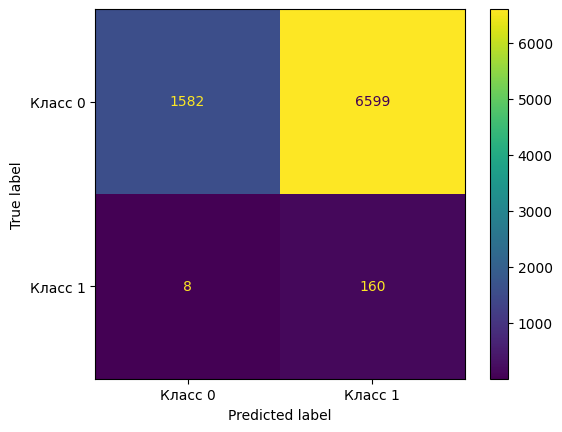

In [138]:
cm = confusion_matrix(y_test, pred_test_2_threshold)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1']).plot()
plt.show()

In [139]:
1590/8349

0.19044196909809558

Модель отнесла очень 81% к классу 1. Когда фактически к классу 1 относится 2% выборки.

**Теперь применим порог 0,02.**

In [140]:
pred_test_2_threshold = pd.DataFrame(zip(y_test, probabilities_test_2[:,1]), columns = ['y_test', 'probabilities_test_2'])
pred_test_2_threshold['y_pred_0.02'] = pred_test_2_threshold['probabilities_test_2'].apply(lambda x: 1 if x >= 0.02 else 0)
pred_test_2_threshold.head()

,y_test,probabilities_test_2,y_pred_0.02
0,0,0.006889,0
1,0,0.020823,1
2,0,0.009514,0
3,0,0.014439,0
4,0,0.006945,0


In [141]:
pred_test_2_threshold = pred_test_2_threshold['y_pred_0.02']

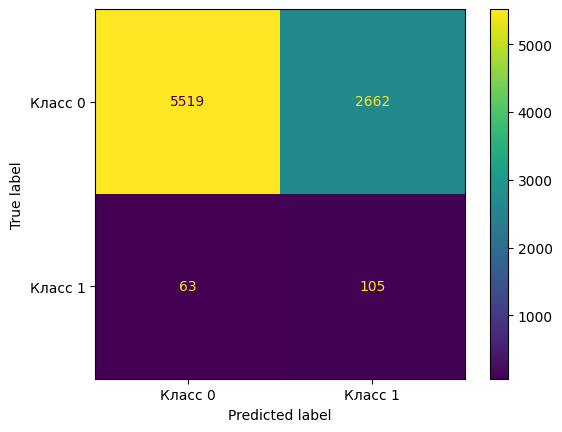

In [142]:
cm = confusion_matrix(y_test, pred_test_2_threshold)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1']).plot()
plt.show()

In [143]:
2767/8349

0.33141693616001916

In [144]:
105/168

0.625

In [145]:
105/2662

0.03944402704733283

In [146]:
63/5519

0.011415111433230658

**С порогом 0,02 модель отнесла к классу 1 33% выборки, нашла 62,5% объектов с реальным классом 1.**

Этот результат далек от идеального, но имеет смысл.

Помним, что на вход модели поданы признаки с низким уровнем корреляции phik с таргетом.

Модель нашла 62,5% клиентов, которые совершат покупку в течение ближайших 90 дней, а также:

- Модель выделила 1/3 выборки клиентов, среди которых есть те (4%), что совершат покупку, остальные имеют отностельно более высокие предпосылки для совершения покупки. При проведении дополнительных маркетинговых мероприятий количество покупок можно увеличить. 

- Модель показала 2/3 выборки клиентов с которыми из соображений экономии средств компании дополнительные маркетинговые мероприятия проводить не стоит. Хоть среди этих клиентов есть те, что покупку таки совершат (1%), но остальные имеют более низкий уровень предпосылок к совершению покупки.

## Вывод

На полученных данных построена модель CatBoostClassifier:

In [147]:
CatBoostClassifier_Model = grid_search_2
CatBoostClassifier_Model

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['category_first_mode',
                                                                          'channel_mode...
                          'models__C': range(1, 2),
                          'preprocessor__num': [StandardScaler(),
                                                'passthrough']},
                         {'models': [CatBoostClassifier(allow_writing_files=False, random_state=38, thread_count=4, verbose=False)],
                          'models__depth': [3, 8],
                          'models__iterations': [80, 100],
                          'models__learning_rate': [0.1, 0.5],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

**Модель принимает следующие признаки:**

- category_first_mode - категория первого уровня, в которой клиент сделал большее количество покупок

- channel_mode - канал получения сообщений, на основании которых клиент сделал большее количество покупок

- price_mean - средняя цена купенного товара

- quantity_sum количество купленных товаров

- year_last_purchase - год, в котором сделана последняя покупка (год выгрузки 2024, предыдущий 2023 или 2022)

- messages_count - количество отправленных клиенту сообщений

- event_mode - наиболее частое действие с сообщением у данного клиента

- purchase_share - доля сообщений, отправленных клиенту, которые привели к покупкам.

Признаки рассчитаны на основе полученных датафреймов  messages_data и purchases_data.

В ходе подготовки признаков и выборок были удалны: дубликаты из датафрейма messages_data, а также более 8 тыс. строк (клиентов), для которых предоставлен таргет, так этих клиентов возникли пропуски признаках из датафрейма messages_data.

**Согласно матрице phik признаки, полученные их данных, имеют низкую корреляцию с таргетом.**


При применении модели рекомендуем использовать **порог значимости для отнесения к классу 1 - 0,02.**

**На тестовой выборке модель порогом 0,02 отнесла к классу 1 33% выборки при фактической доле класса 1, равной 2%.**

Этот результат далек от идеального, но имеет смысл.

**Модель нашла 62,5% клиентов, которые совершат покупку в течение ближайших 90 дней**, а также:

- **Модель выделила 1/3 выборки клиентов, среди которых есть те (4%), что совершат покупку**, остальные имеют отностельно более высокие предпосылки для совершения покупки. При проведении дополнительных маркетинговых мероприятий количество покупок можно увеличить.

- **Модель показала 2/3 выборки клиентов с которыми из соображений экономии средств компании дополнительные маркетинговые мероприятия проводить не стоит.** Хоть среди этих клиентов есть те, что покупку таки совершат (1%), но остальные имеют более низкий уровень предпосылок к совершению покупки.